khudka laksh dhundne u ghumja ki manjil tera pata puchee.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import math, copy


In [26]:
import os
print(os.listdir())


['gradient_descent.ipynb']


In [27]:
# House sizes (sq ft)
x_train = np.array([500, 800, 1000, 1200, 1500])

# House prices (lakhs)
y_train = np.array([80, 125, 155, 165, 180])


TO COMPUTE COST FUNC 

In [28]:
def compute_cost(x , y , w , b):
    m = x.shape[0]
    cost = 0 

    for i in range(m):
        f_wb = w*x[i] + b
        cost += (f_wb - y[i])**2
    total_cost = cost/(2*m)
    return total_cost

COMPUTE GRADIENT

In [29]:
def gradient(x , y ,w ,b):
    m = x.shape[0]
    dw = 0
    db = 0

    for i in range(m):
        f_wb = w*x[i] + b
        dw +=  (f_wb - y[i])*x[i]
        db +=  (f_wb -y[i])*1
        
    db = db/m
    dw = dw/m

    return dw , db

In [37]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
     J_history = [] #this is to store all cost func
     p_history = []
     w = w_in
     b = b_in

     for i in range(num_iters):
          dw , db = gradient_function(x , y ,w ,b)

          w = w - alpha*dw
          b = b - alpha*db

          if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])

          if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]} ",
                  f"dw: {dw}, db: {db}  ",
                  f"w: {w}, b:{b}")
 
     return w, b, J_history, p_history

In [40]:
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-6
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, gradient)
print(f"(w,b) found by gradient descent: ({w_final},{b_final})")

Iteration    0: Cost 274.75371560994034  dw: -152600.0, db: -141.0   w: 0.15259999999999999, b:0.00014099999999999998
Iteration 1000: Cost 134.34509932609433  dw: 0.003818270657211542, db: -4.261189646126647   w: 0.13673442259894747, b:0.004388197844877586
Iteration 2000: Cost 134.3269434643784  dw: 0.003817873810476158, db: -4.2607467501236185   w: 0.1367306045269316, b:0.008649165817718444
Iteration 3000: Cost 134.30879137660412  dw: 0.0038174769695615398, db: -4.26030390015398   w: 0.13672678685175535, b:0.012909690917596344
Iteration 4000: Cost 134.29064306198697  dw: 0.003817080166481901, db: -4.259861096212918   w: 0.13672296957337746, b:0.017169773190542276
Iteration 5000: Cost 134.27249851974312  dw: 0.00381668345653452, db: -4.259418338295601   w: 0.1367191526917567, b:0.021429412682582458
Iteration 6000: Cost 134.25435774908755  dw: 0.003816286746587139, db: -4.258975626397325   w: 0.1367153362068518, b:0.02568860943973826
Iteration 7000: Cost 134.2362207492372  dw: 0.0038158

In [45]:
print(f"1000 sqft house prediction {w_final*1000.0 + b_final} lakh Rupee")
print(f"1200 sqft house prediction {w_final*1200 + b_final}lakh Rupee")
print(f"2000 sqft house prediction {w_final*550 + b_final} lakh rupee")

1000 sqft house prediction 136.74279476110144 lakh Rupee
1200 sqft house prediction 164.0828103707548lakh Rupee
2000 sqft house prediction 75.22775963938132 lakh rupee


In [33]:
print(f"{w_final*0.5 + b_final:0.1f}")

0.1


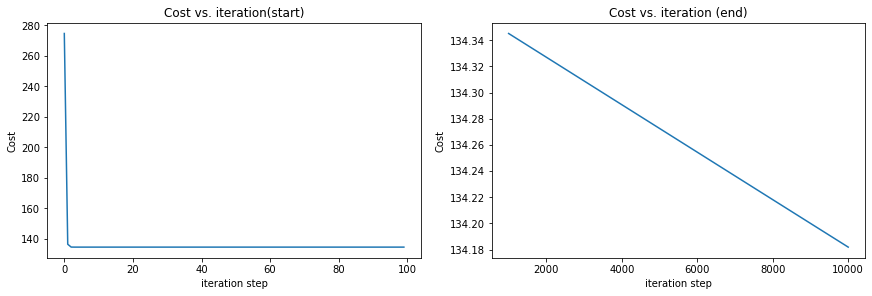

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()